# Мультимодальный RAG-пайплайн: Результаты анализа

**Система:** Мультимодальная RAG для русско-казахских технических документов  
**Типы блоков:** header, text, list, table, no_text → chart, image  
**ИИ-модели:** CLIP, BLIP, SBERT, GPT API

---
## 1. Настройка среды

In [1]:
import sys, os, logging
import warnings
warnings.filterwarnings('ignore')

# Корень проекта
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

# Логирование
logging.basicConfig(level=logging.INFO, format='%(name)s - %(message)s')
logger = logging.getLogger('notebook')

# Путь к PDF
PDF_PATH = 'data/input_pdfs/diploma_example.pdf'
print(f'PDF: {PDF_PATH}')
print(f'Exists: {os.path.exists(PDF_PATH)}')

PDF: data/input_pdfs/diploma_example.pdf
Exists: True


In [2]:
# Проверка зависимостей
print('=== Проверка зависимостей ===')

# Tesseract OCR
try:
    import pytesseract
    version = pytesseract.get_tesseract_version()
    print(f'Tesseract OCR: v{version}')
except Exception as e:
    print(f'Tesseract OCR: НЕ УСТАНОВЛЕН!')
    print(f'  Скачайте: https://github.com/UB-Mannheim/tesseract/wiki')
    print(f'  При установке выберите языки: Russian, Kazakh, English')
    print(f'  Добавьте в PATH: C:\\Program Files\\Tesseract-OCR')

# PyMuPDF
import fitz
print(f'PyMuPDF: v{fitz.version[0]}')

# transformers (CLIP, BLIP)
try:
    import transformers
    print(f'Transformers: v{transformers.__version__}')
except ImportError:
    print('Transformers: НЕ УСТАНОВЛЕН (pip install transformers)')

# sentence-transformers (SBERT)
try:
    import sentence_transformers
    print(f'Sentence-Transformers: v{sentence_transformers.__version__}')
except ImportError:
    print('Sentence-Transformers: НЕ УСТАНОВЛЕН')

# FAISS
try:
    import faiss
    print(f'FAISS: OK')
except ImportError:
    print('FAISS: НЕ УСТАНОВЛЕН (pip install faiss-cpu)')

print()
print(f'Документ: {os.path.basename(PDF_PATH)}')
print(f'Страниц: {len(fitz.open(PDF_PATH))}')

=== Проверка зависимостей ===
Tesseract OCR: v5.5.0
PyMuPDF: v1.27.2
Transformers: v5.3.0


faiss.loader - Loading faiss with AVX2 support.
faiss.loader - Successfully loaded faiss with AVX2 support.


Sentence-Transformers: v5.3.0
FAISS: OK

Документ: diploma_example.pdf
Страниц: 41


---
## 2. Этап 1 — Извлечение блоков из PDF

PyMuPDF извлекает текстовые блоки и изображения.  
`BlockClassifier` (правила, без ИИ) определяет тип: **header**, **text**, **list**, **table**, **no_text**.

In [3]:
import fitz
from src.pipeline.page_analyzer import PageAnalyzer

doc = fitz.open(PDF_PATH)
analyzer = PageAnalyzer()

all_blocks = []
for page_num in range(len(doc)):
    page = doc[page_num]
    blocks = analyzer.analyze_page(page, page_num + 1)
    all_blocks.extend(blocks)
doc.close()

print(f'Всего страниц: {len(fitz.open(PDF_PATH))}')
print(f'Всего блоков: {len(all_blocks)}')
print()

# Подсчёт типов
from collections import Counter
type_counts = Counter(b.block_type for b in all_blocks)
for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f'  {t:10s}: {c}')

Всего страниц: 41
Всего блоков: 214

  text      : 77
  table     : 77
  no_text   : 38
  header    : 12
  list      : 10


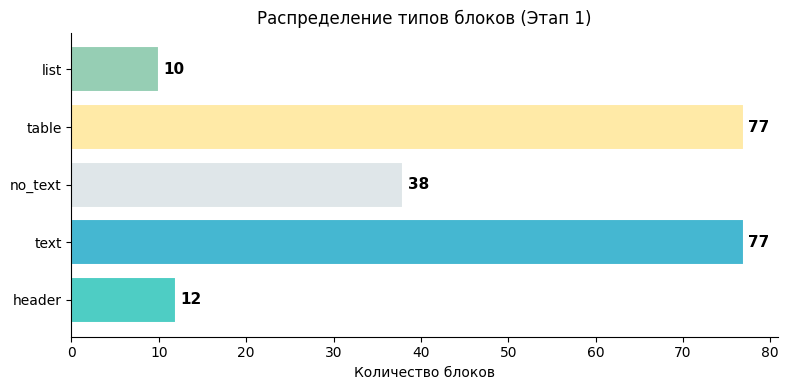

Сохранено: report/img/block_types.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(8, 4))
types = list(type_counts.keys())
counts = list(type_counts.values())
colors_map = {
    'header': '#4ECDC4', 'text': '#45B7D1', 'list': '#96CEB4',
    'table': '#FFEAA7', 'no_text': '#DFE6E9', 'chart': '#FF6B6B',
    'image': '#A29BFE'
}
bar_colors = [colors_map.get(t, '#95A5A6') for t in types]

bars = ax.barh(types, counts, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Количество блоков')
ax.set_title('Распределение типов блоков (Этап 1)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
os.makedirs('report/img', exist_ok=True)
plt.savefig('report/img/block_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: report/img/block_types.png')

In [5]:
# Примеры каждого типа блока
print('=' * 60)
print('ПРИМЕРЫ БЛОКОВ ПО ТИПАМ')
print('=' * 60)

shown_types = set()
for block in all_blocks:
    if block.block_type not in shown_types and block.text:
        shown_types.add(block.block_type)
        text_preview = block.text[:120].replace('\n', ' ')
        if len(block.text) > 120:
            text_preview += '...'
        print(f'\n[{block.block_type:10s}] Стр. {block.page_num}:')
        print(f'  {text_preview}')

ПРИМЕРЫ БЛОКОВ ПО ТИПАМ

[header    ] Стр. 1:
  МИНИСТЕРСТВО ОБРАЗОВАНИЯ И НАУКИ РЕСПУБЛИК КАЗАХСТАН

[text      ] Стр. 1:
  Казахский национальный исследовательский технический университет

[table     ] Стр. 4:
  1 M. C. RAO. Pulsed laser deposition -ablation mechanism andapplications  // Modern Physics. – 2013. – Vol. 22. – Р. 355...

[no_text   ] Стр. 11:
  12

[list      ] Стр. 11:
  1.1  Метод импульсного лазерного осаждения (PLD)  12    1.2  Рост пленки на поверхности подложки  15    1.3  Оксидные ма...


---
## 3. Этап 2 — Классификация изображений (CLIP)

Все блоки `no_text` — это изображения. CLIP (ИИ) смотрит на каждое и определяет:
- **chart** — графики, диаграммы, гистограммы (нужна транскрипция)
- **image** — фотографии, логотипы, схемы (краткое описание)

In [6]:
from src.preprocessing.image_extractor import ImageExtractor
from src.preprocessing.image_captioner import ImageClassifier

# Извлечение изображений
extractor = ImageExtractor(min_width=50, min_height=50)
doc_name = os.path.splitext(os.path.basename(PDF_PATH))[0]
images_dir = os.path.join('data/images', doc_name)
extracted_images = extractor.extract_from_pdf(PDF_PATH, output_dir=images_dir)
print(f'Извлечено изображений: {len(extracted_images)}')

# CLIP классификация
classifier = ImageClassifier(use_clip=True)

if extracted_images:
    classifications = classifier.classify_batch(extracted_images)

    # Разделение
    chart_images = [
        (img, cls) for img, cls in zip(extracted_images, classifications)
        if cls['block_type'] == 'chart'
    ]
    photo_images = [
        (img, cls) for img, cls in zip(extracted_images, classifications)
        if cls['block_type'] == 'image'
    ]

    print(f'\nРезультаты CLIP:')
    print(f'  Charts (графики): {len(chart_images)}')
    print(f'  Images (фото):    {len(photo_images)}')
    print()
    for i, (img, cls) in enumerate(zip(extracted_images, classifications)):
        bt = cls['block_type']
        cs = cls['chart_score']
        ims = cls['image_score']
        conf = cls['confidence']
        print(f'  [{i+1}] Стр. {img.page_num+1}: {bt:5s}  '
              f'(chart={cs:.3f}, image={ims:.3f}, conf={conf:.3f})')
else:
    chart_images = []
    photo_images = []
    print('Изображения не найдены.')

src.preprocessing.image_extractor - Извлечение изображений из: data/input_pdfs/diploma_example.pdf (41 страниц)
src.preprocessing.image_extractor - Извлечено 35 уникальных изображений (отфильтровано: 0 дубликатов)
src.preprocessing.image_captioner -   Классификация [1/35]: стр. 2, 1087x1536px
src.preprocessing.image_captioner - Загрузка CLIP модели (openai/clip-vit-base-patch32)...


Извлечено изображений: 35


httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
huggingface_hub.utils._http - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetenso

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
httpx - HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
httpx -


Результаты CLIP:
  Charts (графики): 11
  Images (фото):    24

  [1] Стр. 2: image  (chart=0.042, image=0.291, conf=0.873)
  [2] Стр. 3: image  (chart=0.043, image=0.290, conf=0.871)
  [3] Стр. 5: chart  (chart=0.218, image=0.115, conf=0.654)
  [4] Стр. 7: image  (chart=0.023, image=0.310, conf=0.931)
  [5] Стр. 8: image  (chart=0.004, image=0.329, conf=0.987)
  [6] Стр. 14: chart  (chart=0.205, image=0.129, conf=0.614)
  [7] Стр. 15: image  (chart=0.018, image=0.315, conf=0.946)
  [8] Стр. 16: image  (chart=0.012, image=0.322, conf=0.965)
  [9] Стр. 23: chart  (chart=0.264, image=0.070, conf=0.791)
  [10] Стр. 23: chart  (chart=0.182, image=0.151, conf=0.546)
  [11] Стр. 26: image  (chart=0.032, image=0.302, conf=0.905)
  [12] Стр. 26: image  (chart=0.002, image=0.331, conf=0.994)
  [13] Стр. 26: image  (chart=0.067, image=0.266, conf=0.799)
  [14] Стр. 27: image  (chart=0.001, image=0.332, conf=0.996)
  [15] Стр. 28: chart  (chart=0.203, image=0.130, conf=0.609)
  [16] Стр. 28: cha

---
## 4. Этап 3 — Транскрипция графиков (OCR + CLIP + BLIP + GPT)

Каждый **chart** проходит полный анализ:
1. **OCR** — читает текст с графика (подписи, числа)
2. **CLIP** — определяет подтип (столбчатая, линейная, круговая...)
3. **BLIP** — генерирует описание на английском
4. **GPT** — переводит и дополняет описание на русском

Результат: **транскрипция** — текстовое описание графика для RAG.

In [7]:
from src.preprocessing.chart_analyzer import ChartAnalyzer
from src.preprocessing.ocr_processor import OCRProcessor

ocr = OCRProcessor()
chart_analyzer = ChartAnalyzer(
    ocr_processor=ocr,
    use_clip=True,
    use_blip=True,
    use_opencv=True,
)

chart_only_images = [img for img, cls in chart_images]
chart_results = []

if chart_only_images:
    chart_results = chart_analyzer.analyze_batch(chart_only_images)
    print(f'Проанализировано графиков: {len(chart_results)}')
    for i, r in enumerate(chart_results):
        print(f'\n--- График {i+1} (стр. {r.page_num}) ---')
        print(f'  Подтип (CLIP): {r.chart_subtype_ru} (conf={r.confidence:.2f})')
        blip = r.blip_caption
        print(f'  BLIP: {blip[:80]}...' if len(blip) > 80 else f'  BLIP: {blip}')
        ocr_t = r.ocr_text
        print(f'  OCR текст: {ocr_t[:100]}...' if len(ocr_t) > 100 else f'  OCR текст: {ocr_t}')
        gpt = r.gpt_description
        print(f'  GPT описание: {gpt[:150]}...' if len(gpt) > 150 else f'  GPT описание: {gpt}')
else:
    print('Графики не найдены в документе.')

src.preprocessing.chart_analyzer -   Анализ графика [1/11]: стр. 5, 1087x1536px
src.preprocessing.chart_analyzer - Загрузка CLIP для анализа графиков...
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 40

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
httpx - HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors.index.json "HTTP/1.1 404 Not Found"
httpx - HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors "HTTP/1.1 302

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
httpx - HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/config.json "HTTP/1.1 307 Temporary Re

Проанализировано графиков: 11

--- График 1 (стр. 5) ---
  Подтип (CLIP): Таблица с данными (conf=0.44)
  BLIP: this image shows a black document with a picture of a person in a suit
  OCR текст: ТРАФИК у
| Нбпаевонанив разделов, | Срожи предотаврезния Понмечание
перечень научному руководжтело
т...
  GPT описание: Таблица с данными. (BLIP: this image shows a black document with a picture of a person in a suit). Ключевые слова: ТРАФИК, Нбпаевонанив, разделов, Сро...

--- График 2 (стр. 14) ---
  Подтип (CLIP): Блок-схема (conf=0.82)
  BLIP: this image shows a diagram of a circular space station
  OCR текст: aii
о COT |
5. é Xe ТЕ
2 =
  GPT описание: Тип визуализации – блок‑схема, изображающая круглую космическую

--- График 3 (стр. 23) ---
  Подтип (CLIP): Диаграмма с областями (conf=0.26)
  BLIP: this image shows a diagram of a circle with a center and a center
  OCR текст: 
  GPT описание: Диаграмма с областями. (BLIP: this image shows a diagram of a circle with a center and a center)

---
## 5. Визуализация: Оригинал графика → Транскрипция

Наглядная демонстрация для научного руководителя:  
**слева** — исходное изображение, **справа** — результат анализа системы.

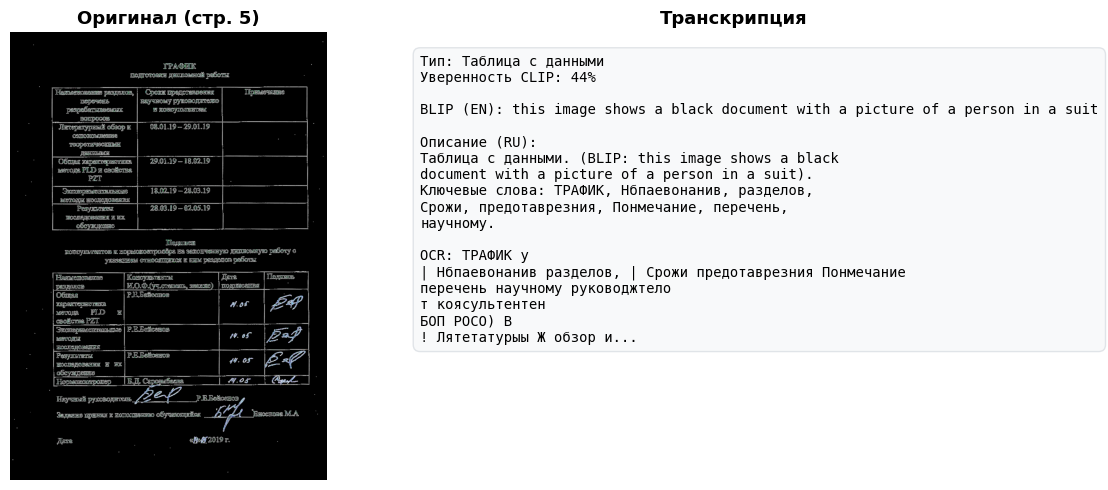

Сохранено: report/img/chart_recognition_1.png



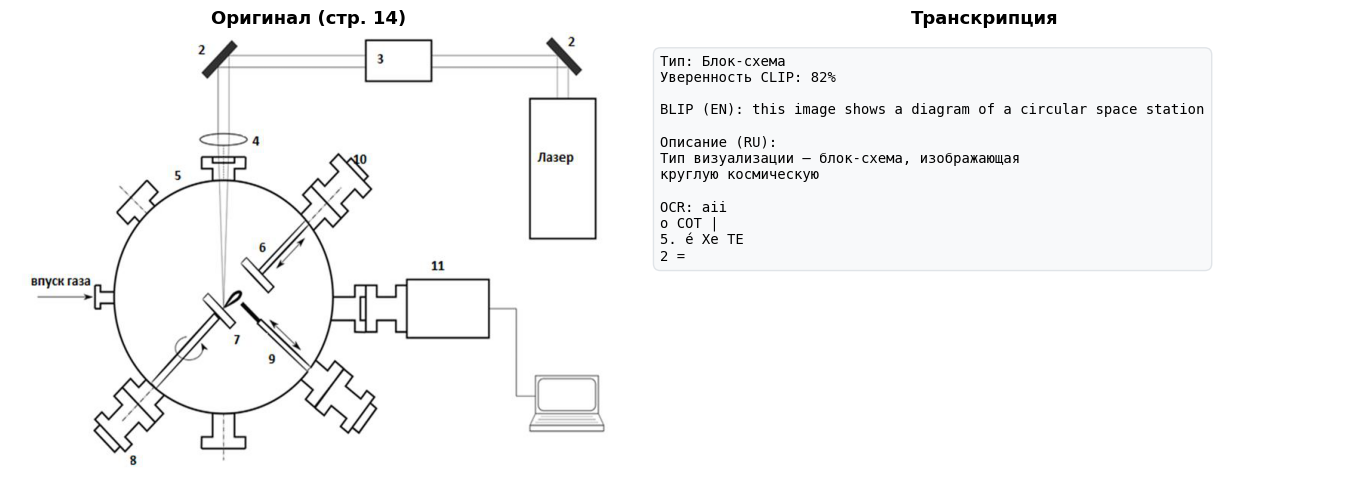

Сохранено: report/img/chart_recognition_2.png



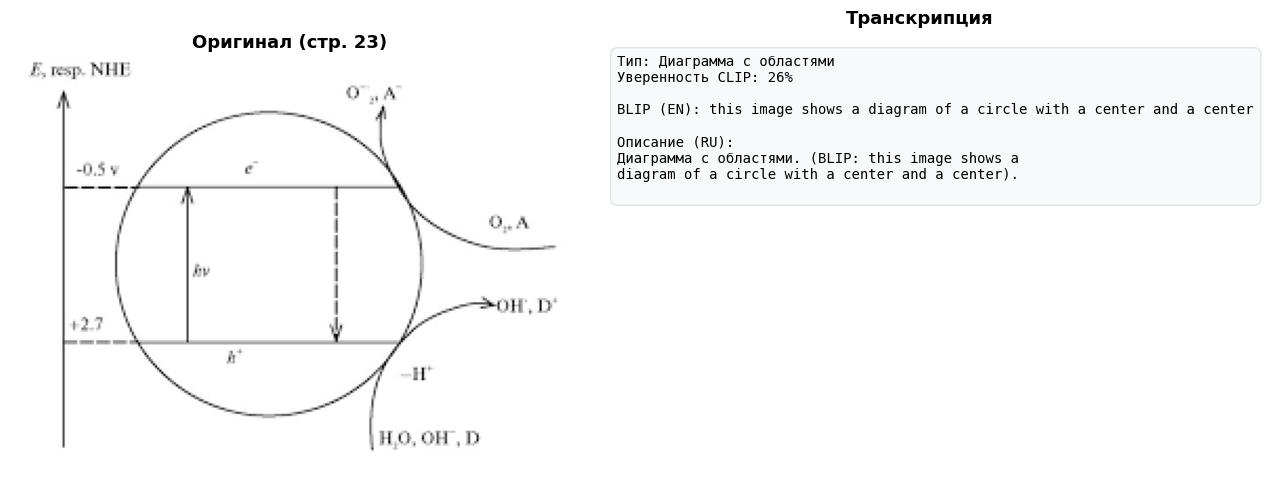

Сохранено: report/img/chart_recognition_3.png



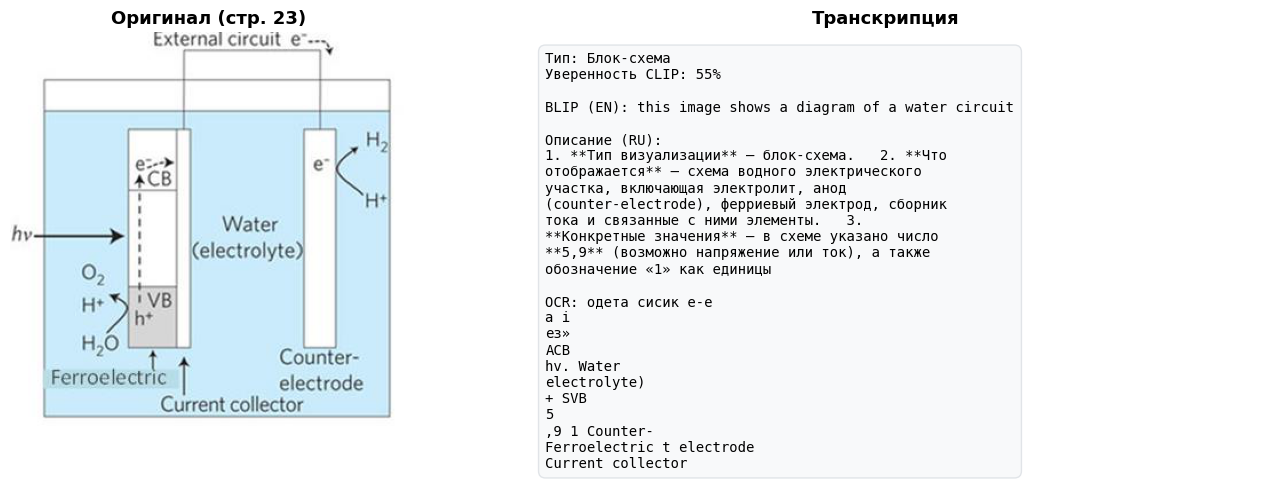

Сохранено: report/img/chart_recognition_4.png



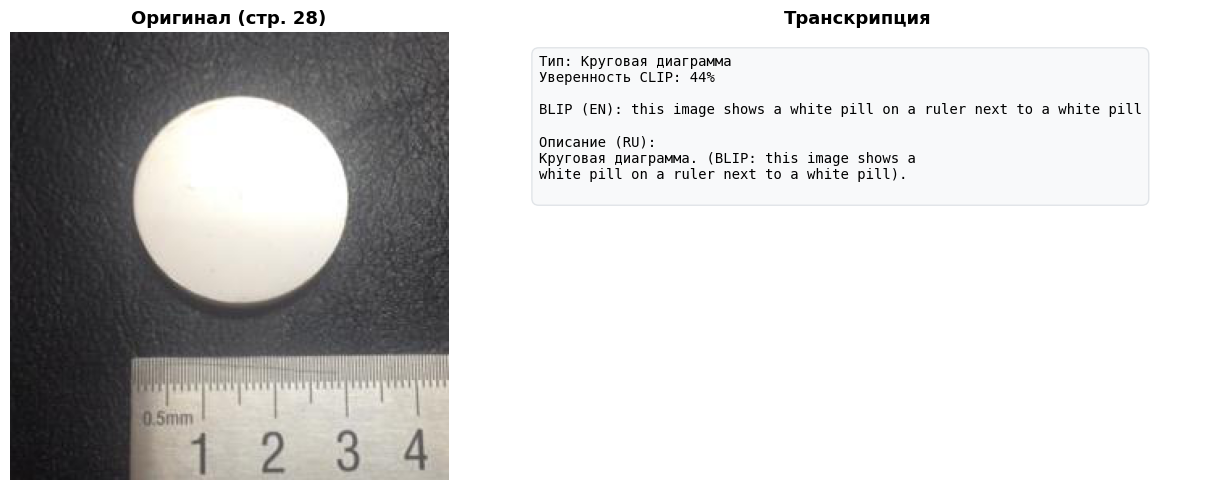

Сохранено: report/img/chart_recognition_5.png



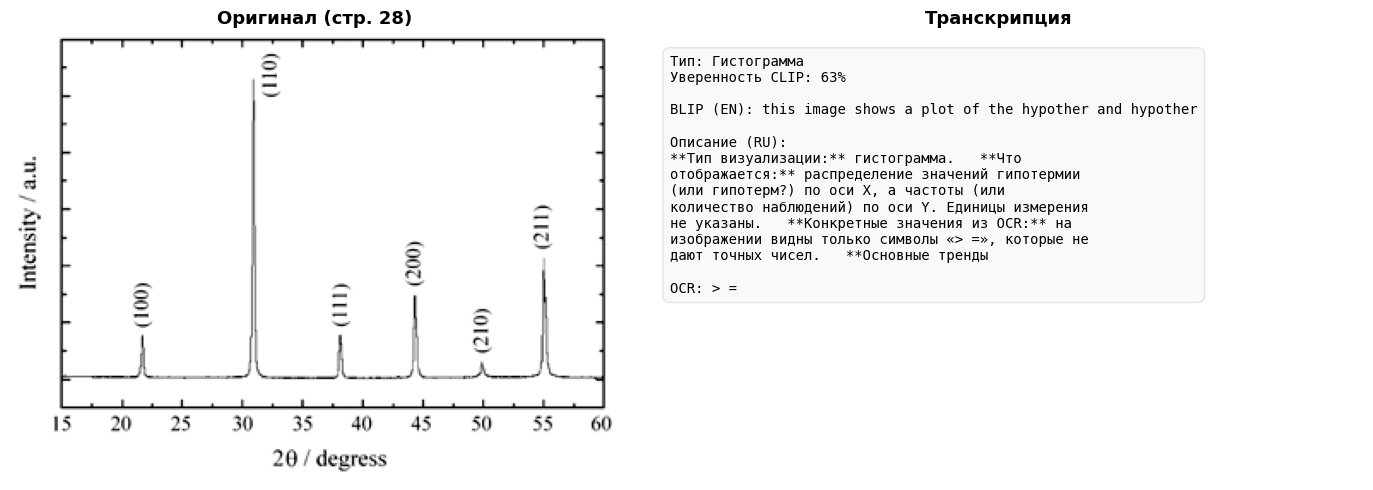

Сохранено: report/img/chart_recognition_6.png



In [8]:
import textwrap

if chart_results and chart_only_images:
    n_charts = min(len(chart_results), 6)

    for idx in range(n_charts):
        img_data = chart_only_images[idx]
        analysis = chart_results[idx]

        fig, (ax_img, ax_text) = plt.subplots(
            1, 2, figsize=(14, 5),
            gridspec_kw={'width_ratios': [1, 1.2]}
        )

        # Левая часть — оригинальное изображение
        ax_img.imshow(img_data.image)
        ax_img.set_title(
            f'Оригинал (стр. {analysis.page_num})',
            fontsize=13, fontweight='bold'
        )
        ax_img.axis('off')

        # Правая часть — транскрипция
        ax_text.axis('off')

        lines = []
        lines.append(f"Тип: {analysis.chart_subtype_ru}")
        lines.append(f"Уверенность CLIP: {analysis.confidence:.0%}")
        lines.append("")
        if analysis.blip_caption:
            lines.append(f"BLIP (EN): {analysis.blip_caption}")
            lines.append("")
        if analysis.gpt_description:
            wrapped = textwrap.fill(analysis.gpt_description, width=50)
            lines.append(f"Описание (RU):")
            lines.append(wrapped)
            lines.append("")
        if analysis.ocr_text:
            ocr_short = analysis.ocr_text[:150]
            if len(analysis.ocr_text) > 150:
                ocr_short += '...'
            lines.append(f"OCR: {ocr_short}")

        transcription = "\n".join(lines)

        ax_text.text(
            0.05, 0.95, transcription,
            transform=ax_text.transAxes,
            verticalalignment='top',
            fontsize=10, fontfamily='monospace',
            bbox=dict(
                boxstyle='round,pad=0.5',
                facecolor='#F8F9FA',
                edgecolor='#DEE2E6', alpha=0.9
            )
        )
        ax_text.set_title('Транскрипция', fontsize=13, fontweight='bold')

        plt.tight_layout()
        save_path = f'report/img/chart_recognition_{idx+1}.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Сохранено: {save_path}')
        print()
else:
    print('Нет графиков для визуализации.')

---
## 6. Markdown и Chunking

Все блоки (текст + графики + фото) собираются в Markdown → разбиваются на чанки.

In [9]:
from src.preprocessing.markdown_builder import MarkdownBuilder
from src.rag.chunker import MarkdownChunker
from src.layout.block import Block

# Создаём Block-объекты для chart и image
chart_blocks = []
for img_data, analysis in zip(chart_only_images, chart_results):
    chart_blocks.append(Block(
        block_type='chart',
        bbox=img_data.bbox,
        page_num=img_data.page_num + 1,
        text=analysis.to_chunk_text(),
        metadata=analysis.to_dict(),
    ))

image_blocks = []
for img_data, cls in photo_images:
    image_blocks.append(Block(
        block_type='image',
        bbox=img_data.bbox,
        page_num=img_data.page_num + 1,
        metadata={'image_path': img_data.saved_path or '', 'ocr_text': ''},
    ))

final_blocks = all_blocks + chart_blocks + image_blocks
print(f'Итого блоков для Markdown: {len(final_blocks)}')
print(f'  Текстовых: {len(all_blocks)}')
print(f'  Графиков:  {len(chart_blocks)}')
print(f'  Фото:      {len(image_blocks)}')

# Markdown
builder = MarkdownBuilder()
source_name = os.path.basename(PDF_PATH)
markdown = builder.build(final_blocks, source_name)
print(f'\nMarkdown: {len(markdown)} символов')

# Сохранение
md_dir = os.path.join('data/indexes', doc_name)
os.makedirs(md_dir, exist_ok=True)
md_path = os.path.join(md_dir, source_name + '.md')
builder.save(markdown, md_path)

# Chunking
chunker = MarkdownChunker(
    max_chunk_size=1000, chunk_overlap=100, min_chunk_size=50
)
chunks = chunker.chunk_markdown(markdown, source=source_name)
print(f'Чанков: {len(chunks)}')

src.preprocessing.markdown_builder - Markdown saved to data/indexes/diploma_example/diploma_example.pdf.md
src.rag.chunker - Created 76 chunks from 'diploma_example.pdf'


Итого блоков для Markdown: 249
  Текстовых: 214
  Графиков:  11
  Фото:      24

Markdown: 69318 символов
Чанков: 76


In [10]:
# Пример чанка с транскрипцией графика (если есть)
chart_chunk_found = False
for c in chunks:
    if '[Тип:' in c.text or 'График' in c.text:
        print('=== Пример чанка с транскрипцией графика ===')
        print(c.text)
        print(f'\n(Размер: {len(c.text)} символов)')
        chart_chunk_found = True
        break

if not chart_chunk_found:
    print('Пример текстового чанка:')
    print(chunks[0].text[:500])

=== Пример чанка с транскрипцией графика ===
-- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |

| Температура подложки измерялась термопарой вида “K”. Перед | осаждением проводилась откачка камеры вплоть до вакуума 10 -6 | Торр, далее | в камеру запускался поток О 2 . Энергия лазера и частота задавалась | программой с пульта управления. Лазерный луч фокусировался линзой с | целью получения пучка диаметр 1мм, что был нацелен через оптическое |
| --- | --- | --- | --- | --- | --- |

---
*Страница 31*

окошко в центр вращающейся мишени. Энергия лазера воздействовала на  поверхность PZT мишени с частотой с 5 вплоть до 20Гц, образовывая факел  из испаренных элементов мишени которые осаждались в подогретую  поверхность подложки.

Рисунок 3.9 – График программируемого нагрева термостолика

| Пленки PZT осаждались в подложке химически расчищенного Ni 100 | согласно характеристикам, отмеченным в таблице 3.1. |
| --- | --- |

Таблица 3.1- Параме

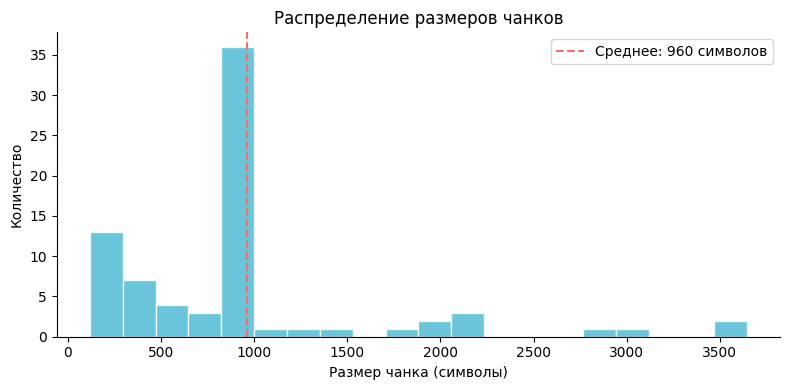

Мин: 118, Макс: 3646, Среднее: 960


In [11]:
sizes = [len(c.text) for c in chunks]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sizes, bins=20, color='#45B7D1', edgecolor='white', alpha=0.8)
ax.axvline(
    x=sum(sizes)/len(sizes), color='#FF6B6B', linestyle='--',
    label=f'Среднее: {sum(sizes)/len(sizes):.0f} символов'
)
ax.set_xlabel('Размер чанка (символы)')
ax.set_ylabel('Количество')
ax.set_title('Распределение размеров чанков')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('report/img/chunk_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Мин: {min(sizes)}, Макс: {max(sizes)}, Среднее: {sum(sizes)/len(sizes):.0f}')

---
## 7. Эмбеддинги (SBERT) и индексация (FAISS)

In [12]:
from src.rag.embedder import MultimodalEmbedder
from src.rag.vector_store import FAISSVectorStore

embedder = MultimodalEmbedder(use_clip=False)
embeddings = embedder.embed_chunks(chunks)
print(f'Эмбеддинги: shape={embeddings.shape}')
print(f'Размерность: {embeddings.shape[1]}')

# FAISS
vector_store = FAISSVectorStore(dimension=embedder.dimension)
metadata_list = [chunk.to_dict() for chunk in chunks]
vector_store.add(embeddings, metadata_list)

# Сохранение
index_dir = os.path.join('data/indexes', doc_name)
os.makedirs(index_dir, exist_ok=True)
vector_store.save(index_dir)
print(f'Индекс сохранён: {index_dir}')
print(f'Чанков в индексе: {vector_store.size}')

src.rag.embedder - Loading text embedding model: paraphrase-multilingual-MiniLM-L12-v2
sentence_transformers.SentenceTransformer - Use pytorch device_name: cpu
sentence_transformers.SentenceTransformer - Load pretrained SentenceTransformer: paraphrase-multilingual-MiniLM-L12-v2
httpx - HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/modules.json "HTTP/1.1 200 OK"
httpx - HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
httpx - HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/config.json "HTTP/1.1 200 OK"
httpx - HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-

Эмбеддинги: shape=(76, 384)
Размерность: 384
Индекс сохранён: data/indexes/diploma_example
Чанков в индексе: 76


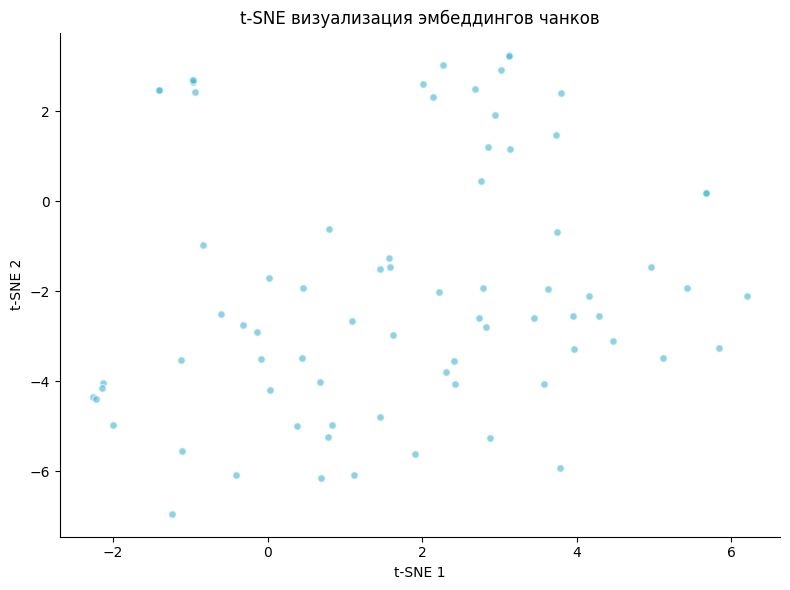

Сохранено: report/img/tsne_embeddings.png


In [13]:
from sklearn.manifold import TSNE
import numpy as np

if embeddings.shape[0] > 5:
    perplexity = min(30, embeddings.shape[0] - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    coords = tsne.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        coords[:, 0], coords[:, 1],
        c='#45B7D1', alpha=0.6, s=30, edgecolors='white'
    )
    ax.set_title('t-SNE визуализация эмбеддингов чанков')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('report/img/tsne_embeddings.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Сохранено: report/img/tsne_embeddings.png')
else:
    print('Слишком мало чанков для t-SNE')

---
## 8. RAG: Вопрос-Ответ по документу

Задаём вопросы — система ищет релевантные чанки через FAISS и генерирует ответ через GPT.  
Включены вопросы как по тексту, так и **по графикам** для проверки транскрипции.

In [14]:
from src.rag.retriever import MultimodalRetriever
from src.rag.generator import RAGGenerator

retriever = MultimodalRetriever(
    embedder=embedder,
    vector_store=vector_store,
    top_k=5,
)
generator = RAGGenerator(model_name='gpt-oss-20b')
print(f'LLM доступен: {generator.is_available()}')

def ask(question):
    """Задать вопрос RAG-системе."""
    print(f'\n{"=" * 60}')
    print(f'Вопрос: {question}')
    print(f'{"=" * 60}')

    # Retrieval
    results = retriever.retrieve(question, top_k=5)
    context_parts = []
    for i, r in enumerate(results, 1):
        chunk_type = r.get('type', 'text')
        label = 'график' if chunk_type == 'image_caption' else 'текст'
        context_parts.append(f'[Фрагмент {i}, {label}]:\n{r["text"]}')

    context = '\n\n---\n\n'.join(context_parts)

    # Generation
    result = generator.generate(question, context)

    print(f'\nОтвет ({result["model"]}):')
    print(result['answer'])

    print(f'\nИсточники:')
    for i, r in enumerate(results[:3], 1):
        score = r.get('score', 0)
        page = r.get('page', '?')
        preview = r.get('text', '')[:80]
        print(f'  [{i}] Стр. {page}, score={score:.4f}: {preview}...')

    return result

LLM доступен: True


In [15]:
# Вопрос 1: общий
q1 = ask('О чём этот документ?')

src.rag.retriever - Retrieved 5 chunks for query: 'О чём этот документ?...' (filter=None)



Вопрос: О чём этот документ?

Ответ (gpt-oss-20b):
Документ — дипломная работа (дипломная работа по техническому/физико‑математическому направлению).  
В ней рассматривается установка импульсного лазерного осаждения (PLD) и производство тонких пленок Pb(Zr₀.₅₂Ti₀.₄₈)O₃ (PZT). Цель работы — получить такие пленки и применить их в фотокаталитическом расщеплении воды для производства водорода, что рассматривается как перспективный способ получения чистого топлива в условиях энергетического кризиса. В работе описываются экспериментальная установка, методы осаждения, структура и свойства полученных пленок, а также результаты фотокаталитических испытаний. В документе присутствуют таблицы, блок‑схемы (например, схема водного электрического участка), гистограммы и другие графические материалы, иллюстрирующие экспериментальные данные.

Источники:
  [1] Стр. 14, score=0.5012: ![Таблица с данными, стр. 5](data/images/diploma_example/diploma_example_p5_img3...
  [2] Стр. 28, score=0.4039: ![Блок-с

In [16]:
# Вопрос 2: технологии
q2 = ask('Какие методы и технологии описаны в документе?')

src.rag.retriever - Retrieved 5 chunks for query: 'Какие методы и технологии описаны в документе?...' (filter=None)



Вопрос: Какие методы и технологии описаны в документе?

Ответ (gpt-oss-20b):
В документе описаны следующие методы и технологии, применяемые для получения тонких пленок PZT и их последующего использования в фотокаталитическом расщеплении воды:

| № | Метод / технология | Краткое описание (из контекста) |
|---|--------------------|---------------------------------|
| 1 | **Импульсное лазерное осаждение (PLD)** | Основной метод получения тонких пленок Pb(Zr₀.₅₂Ti₀.₄₈)O₃. Описаны параметры лазера (энергия, длина волны, длительность импульса, частота), условия осаждения (температура подложки, давление, расстояние до мишени) и три режима роста пленки (ступенчатый, послойный, слияние островков). |
| 2 | **Молекулярно‑лучевая эпитаксия (MBE)** | Упомянуто как один из методов получения тонких пленок, позволяющий контролировать границы раздела с точностью до атомного слоя, но отмечены проблемы с контролем стехиометрии и высокой стоимостью. |
| 3 | **Напыление пленок (плазменное распыление)** | 

In [17]:
# Вопрос 3: данные на графиках (проверка транскрипции)
q3 = ask('Какие данные представлены на графиках и диаграммах в документе?')

src.rag.retriever - Retrieved 5 chunks for query: 'Какие данные представлены на графиках и диаграммах...' (filter=None)



Вопрос: Какие данные представлены на графиках и диаграммах в документе?

Ответ (gpt-oss-20b):
**Графики и диаграммы, представленные в документе:**

| № | Вид визуализации | Что отображается | Ключевые данные |
|---|------------------|------------------|-----------------|
| 1 | Гистограмма (стр. 28) | Распределение значений гипотермии (ось X) и частоты наблюдений (ось Y). Единицы измерения не указаны. | На изображении видны только символы «> =», точных чисел нет. |
| 2 | Блок‑схема (стр. 23) | Схема водного электрического участка: электролит, анод (counter‑electrode), ферриевый электрод, сборник тока и связанные элементы. | В схеме указано число **5,9** (вероятно напряжение или ток) и обозначение «1» как единицы. |
| 3 | Диаграмма с областями (стр. 23) | Диаграмма круга с центром. | Описание ограничено: «диаграмма круга с центром». |
| 4 | Гистограмма (стр. 33) | Гистограмма, содержащая числовые значения (BNO, eae, ары). | OCR‑текст содержит числа: 25, 2, 255, 15, > 5. Точные интерпрет

In [18]:
# Вопрос 4: тренды из графиков
q4 = ask('Какие тренды или изменения показаны на диаграммах?')

src.rag.retriever - Retrieved 5 chunks for query: 'Какие тренды или изменения показаны на диаграммах?...' (filter=None)



Вопрос: Какие тренды или изменения показаны на диаграммах?

Ответ (gpt-oss-20b):
На основании предоставленного описания диаграмм нельзя однозначно определить конкретные тренды или изменения.  

- **Гистограмма (страница 28)** показывает распределение значений гипотермии по оси X и частоты наблюдений по оси Y, но конкретные числовые значения не доступны.  
- **Диаграмма с областями (страница 23)** описана как «диаграмма круга с центром», что не даёт информации о динамике.  
- **Гистограмма (страница 31)** упоминает «среднее время человека на бег», но OCR‑текст не содержит чисел, а только слова «удержание», «see» и «охлаждение».  
- **Гистограмма (страница 33)** содержит непонятные символы и числа, без контекста, не позволяющего выделить тенденцию.  

Таким образом, из доступных данных нельзя выделить конкретные тренды или изменения, отображаемые на диаграммах.

Источники:
  [1] Стр. 31, score=0.4918: ![Гистограмма, стр. 28](data/images/diploma_example/diploma_example_p28_img16.pn...
  

In [19]:
# Вопрос 5: мультимодальный (текст + графики)
q5 = ask('Сравни данные из таблиц и графиков документа.')

src.rag.retriever - Retrieved 5 chunks for query: 'Сравни данные из таблиц и графиков документа....' (filter=None)



Вопрос: Сравни данные из таблиц и графиков документа.

Ответ (gpt-oss-20b):
В предоставленном контексте нет достаточных точных числовых данных, чтобы провести сравнение между таблицами и графиками.  

- **Таблица 3.1** (фрагмент 3) содержит параметры осаждения пленок (давление, температура, частота лазера и т.д.), но в тексте нет конкретных чисел, которые можно было бы сопоставить с графиками.  
- **Гистограммы** (фрагменты 1, 4, 5) не содержат читаемых числовых значений: OCR‑текст показывает только символы «> =», «rarer», «see» и т.п., без указания осей и точных меток.  

Таким образом, на основании имеющейся информации сравнение данных из таблиц и графиков невозможно. Если появятся точные числовые значения (например, из оригинальных изображений или более точного OCR), можно будет провести более конкретный анализ.

Источники:
  [1] Стр. 31, score=0.3942: ![Гистограмма, стр. 28](data/images/diploma_example/diploma_example_p28_img16.pn...
  [2] Стр. 14, score=0.3941: ![Таблица с данным

---
## 9. Итоговая статистика

In [20]:
print('=' * 50)
print('ИТОГОВАЯ СТАТИСТИКА')
print('=' * 50)
print(f'Документ:  {os.path.basename(PDF_PATH)}')
print(f'Страниц:   {len(fitz.open(PDF_PATH))}')
print()
print('Блоки (этап 1):')
for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f'  {t:10s}: {c}')
print()
print('Изображения (этап 2):')
print(f'  Всего извлечено: {len(extracted_images)}')
print(f'  Charts:          {len(chart_images)}')
print(f'  Images:          {len(photo_images)}')
print()
print('Транскрипции (этап 3):')
print(f'  Графиков проанализировано: {len(chart_results)}')
print()
print('Индекс:')
print(f'  Чанков:      {len(chunks)}')
print(f'  Размерность: {embeddings.shape[1]}')
print(f'  Размер:      {vector_store.size}')

ИТОГОВАЯ СТАТИСТИКА
Документ:  diploma_example.pdf
Страниц:   41

Блоки (этап 1):
  text      : 77
  table     : 77
  no_text   : 38
  header    : 12
  list      : 10

Изображения (этап 2):
  Всего извлечено: 35
  Charts:          11
  Images:          24

Транскрипции (этап 3):
  Графиков проанализировано: 11

Индекс:
  Чанков:      76
  Размерность: 384
  Размер:      76
